In [163]:
import torch
from torch.nn import functional as F
import matplotlib.pyplot as plt

In [2]:
with open('names.txt', 'r') as fname:
    words = fname.read().split()

#### Create Data set and Vocabulary

In [3]:
# build the vocabulary of characters and mappings to/from integers
chrs = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chrs) }
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(stoi)
print(itos)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [4]:
block_size = 3
X = []
Y = []
for word in words[:5]:
    chs = list(word) + ['.']
    context = [0]*block_size
    for ch in chs:
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '----->', itos[ix])
        context = context[1:] + [ix]
        
X = torch.tensor(X)
Y = torch.tensor(Y)

... -----> e
..e -----> m
.em -----> m
emm -----> a
mma -----> .
... -----> o
..o -----> l
.ol -----> i
oli -----> v
liv -----> i
ivi -----> a
via -----> .
... -----> a
..a -----> v
.av -----> a
ava -----> .
... -----> i
..i -----> s
.is -----> a
isa -----> b
sab -----> e
abe -----> l
bel -----> l
ell -----> a
lla -----> .
... -----> s
..s -----> o
.so -----> p
sop -----> h
oph -----> i
phi -----> a
hia -----> .


In [5]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [23]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [16]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

#### Create the neural network

In [42]:
# ============================== Create Embedding Layer ==========================

In [10]:
 # In Original article there are 1700 words with embedding size of 30. Here we use embeding size of 2 for 27 chars
C = torch.randn(27,2)

In [11]:
# we can access the embedding of specific char by a simple indexing
print(C[5])

# Or by assuming "C" as the first layer and by feeding one-hot encoded Inputs. 
F.one_hot(torch.tensor(5), num_classes = 27).float() @ C

tensor([ 0.9659, -0.2696])

In [26]:
# -------------------Here we use Indexing-----------------------

In [40]:
# different types of indexing on a tensor
# C[5]

print(C[[5, 7, 7, 7, 3]].shape)
print(C[[5, 7, 7, 7, 3]])

# we can even index a tensor with multi-dimension array. 
print(C[X].shape)
print(C[X][:2])

torch.Size([5, 2])
tensor([[ 0.9659, -0.2696],
        [ 0.3513, -0.8532],
        [ 0.3513, -0.8532],
        [ 0.3513, -0.8532],
        [ 0.5304,  0.8372]])
torch.Size([32, 3, 2])
tensor([[[-0.0970,  1.0980],
         [-0.0970,  1.0980],
         [-0.0970,  1.0980]],

        [[-0.0970,  1.0980],
         [-0.0970,  1.0980],
         [ 0.9659, -0.2696]]])


In [41]:
# this type of indexing, actually match the embedding C to each chars in X.
# meaning that in X with shape 32,3; it goes in each 32 rows and in each row it goes in each 3 columns
# and get the digits value and use that to index from C ==> for each digits it returns a vector of size 2.
# then the output would be 32,3,2 

# now we created the indexing system from C to extract embeddings according to the Article
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [43]:
# ============================== Create Hidden Layer ==========================

In [58]:
emb[:4]

tensor([[[-0.0970,  1.0980],
         [-0.0970,  1.0980],
         [-0.0970,  1.0980]],

        [[-0.0970,  1.0980],
         [-0.0970,  1.0980],
         [ 0.9659, -0.2696]],

        [[-0.0970,  1.0980],
         [ 0.9659, -0.2696],
         [ 0.3684,  1.0753]],

        [[ 0.9659, -0.2696],
         [ 0.3684,  1.0753],
         [ 0.3684,  1.0753]]])

In [77]:
# the hidden layer would have 100 neurons
# the hidden layer gets input of size 6: every input consist of 3 chars that each of them has embedding of size 2
# Looking to embedding layer shows that it has shape of 32, 3, 2 ==> meaning each sample has shape of 3,2 that totaly 
# makes it have shape of 6
w1 = torch.randn(6, 100)
b1 = torch.randn(100)

# but before feeding embeding layer to hidden layer and do emb @ W, we have to change format of 3, 2 to vector of 6
# by concatenating them.

# unbind returns tuple of size equal to size of define dimension, and each value of tuple are values in other dimensions
# Here we want to concat embeddings of each sample accross the dimension 1. so by using unbind => in each 
# tuple we get all embeddings of all samples.  and by concating these tuples  we get the concatanation of embeddings in 
# a sample

#torch.cat(torch.unbind(emb,1), 1)

# Or we simply can use:

#emb.view(-1,6), # which is equvalent to emb.view(emb.shape[0], 6)

In [78]:
# compute output of hidden layer
h = torch.tanh(emb.view(-1,6) @ w1 + b1)
h

# emb.view(-1,6) @ w1 + b1 ==> 32,6 @ 6,100 -> 32,100 + 100 --> 32,100
# according broadcasting symantic b1 is copied 32 times becoming 32,100 then each of 32 sample would be added to the 
# same b1 vector
#32, 100
#1 , 100 --> 32, 100

tensor([[-0.7072,  0.4184, -0.6131,  ...,  0.5274,  0.9375, -0.9903],
        [ 0.2630,  0.2961, -0.9843,  ...,  0.6087,  0.9930, -0.1048],
        [-0.9377,  0.5135, -0.4503,  ..., -0.0171,  0.9685,  0.6067],
        ...,
        [-0.9622,  0.9947,  0.1925,  ...,  0.8425, -0.6366,  0.9418],
        [-0.9827,  0.9313,  0.9948,  ..., -0.2183, -0.8258,  0.2554],
        [-0.9000,  0.9983,  0.2292,  ...,  0.9919,  0.5780,  0.4998]])

In [75]:
# ============================== Create Output Layer ==========================

In [79]:
w2 = torch.randn(100, 27)
b1 = torch.randn(27)

In [99]:
logits = h @ w2 + b1   #32,100 @ 100,27 --> 32,27
counts = logits.exp()
probs = counts/counts.sum(1, keepdims = True)
loss = -probs[torch.arange(32), Y].log().mean()
loss

tensor(17.4512)

#### Create more respectful version

In [100]:
# 1- create vocabulary
# 2- create data set: X and Y
# 3- Create Neural network's parameters: embedding layer, hiden layer, output layer
# 4- Do optimization: forward path, backward path, update

In [157]:
# 1
voc = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(voc)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [165]:
# 2-
block_size = 3
X = []
Y = []

for word in words:
    chs = list(word) + ['.']
    contex = [0]*block_size
    for ch in chs:
        X.append(contex)
        Y.append(stoi[ch])
        #print(f"{''.join([itos[i] for i in contex])} --------> {ch}")
        contex = contex[1:] + [stoi[ch]]
X = torch.tensor(X)
Y = torch.tensor(Y)
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [166]:
# 3-
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator = g) # Embeddings
w1 = torch.randn((6,100), generator = g)
b1 = torch.randn(100, generator = g)
w2 = torch.randn((100,27), generator = g)
b2 = torch.randn(27, generator = g)

parameters = [C, w1, b1, w2, b2]
for p in parameters:
    p.requires_grad = True
    
num_params = sum([p.nelement() for p in parameters])
print(f'Total num of parameters: {num_params}')

Total num of parameters: 3481


In [160]:
# 
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [185]:
# 4-
lri = []
lossi = []
lrei = []
for i in range(10000):
    # select batch of data
    ix = torch.randint(0,X.shape[0], (32,))
    
        # forward path
    emb = C[X[ix]] # embedding layer : (#sample, #block_size, # embedding_size)
    emb = emb.view(-1, X.shape[1]*2) # reshape embedding layer: (#sample, #block_size * #embedding_size)
    h = torch.tanh(emb @ w1 + b1) # output of hiden layer: (#sample, 100)
    logits = h @ w2 + b2 # (#sample, 27)

    #counts = logits.exp()
    #probs = counts/counts.sum(1, keepdims = True)
    #loss = -probs[torch.arange(X.shape[0]), Y].log().mean()
    #loss.item()
    loss = F.cross_entropy(logits, Y[ix])
    #print(loss.item())

        # backward path
    for p in parameters:
        p.grad = None
    loss.backward()

        # Updating
    #lr = lrs[i]    
    # according to the plot we set lr to 0.1 and after optimizing with this then decay the learning rate to 0.01 
    lr = 0.01
    for p in parameters:
        p.data += -lr*p.grad 
    
    # tracking steps to define learning rate
    # lri.append(lr)
    # lrei.append(lre[i])
    # lossi.append(loss.item())

print(loss.item())    

2.5536577701568604


In [186]:
#calculate True loss on all data set
emb = C[X] 
emb = emb.view(-1, X.shape[1]*2)
h = torch.tanh(emb @ w1 + b1)
logits = h @ w2 + b2 
loss = F.cross_entropy(logits, Y)
print(loss.item())

2.309955596923828


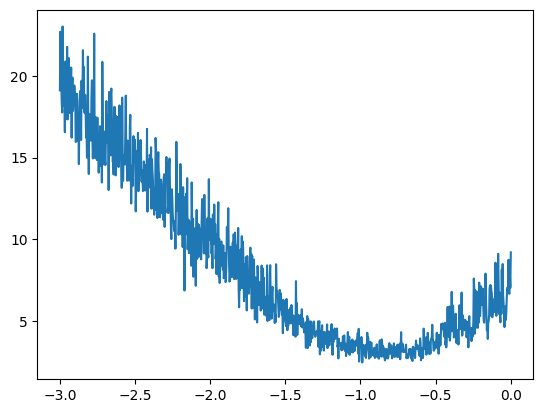

In [164]:
plt.plot(lrei, lossi)

#### Use train/dev/test split approach 

In [187]:
# train split, dev/validation split, test split
# 80%, 10%, 10%
# use for training model's parameters, use for training the model's hyper parameters and settings, Use to evaluate the performance of the model

# training set:
#              use to optimize parameters of the model. Just like we did in previous part using gradient descent.

# dev/validation set:
#              use for development, over all the hyperparameters of the model. hyperparameters are like size of 
#              hidden layer, the size of embedding, the strength of regularization, and the other lots of hyperparameters
#              and settings that go to define the Neural Net. you can try many different variation of them and see 
#              whichever one works best on your validation split.

# test set:
#          use to evaluate the performance of the model. We are only evaluating the loss on the test split 
#          very very sparingly, and very few times. Because every single time you evaluate your test loss and
#          and you learn something from it, you are also starting to train on the test split.

In [200]:
voc = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(voc)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [201]:

def build_dataset(words):
    block_size = 3
    X = []
    Y = []
    for word in words:
        chs = list(word) + ['.']
        contex = [0]*block_size
        for ch in chs:
            X.append(contex)
            Y.append(stoi[ch])
            contex = contex[1:] + [stoi[ch]]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))


Xtr, ytr = build_dataset(words[:n1])
Xdev, ydev = build_dataset(words[n1:n2])
Xtst, ytst = build_dataset(words[n2:])




torch.Size([182424, 3]) torch.Size([182424])
torch.Size([22836, 3]) torch.Size([22836])
torch.Size([22886, 3]) torch.Size([22886])


In [202]:
emb_size = 10
hidden_size = 200
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, emb_size), generator = g) # Embeddings
w1 = torch.randn((3*emb_size, hidden_size), generator = g)
b1 = torch.randn(hidden_size, generator = g)
w2 = torch.randn((hidden_size, 27), generator = g)
b2 = torch.randn(27, generator = g)

parameters = [C, w1, b1, w2, b2]
for p in parameters:
    p.requires_grad = True
    
num_params = sum([p.nelement() for p in parameters])
print(f'Total num of parameters: {num_params}')

Total num of parameters: 11897


In [203]:
lossi = []
stepi = []

In [204]:

for i in range(200000):
    # select batch of data
    ix = torch.randint(0,Xtr.shape[0], (32,))
    
        # forward path
    emb = C[Xtr[ix]] # embedding layer : (#sample, #block_size, # embedding_size)
    emb = emb.view(-1, Xtr.shape[1]*emb_size) # reshape embedding layer: (#sample, #block_size * #embedding_size)
    h = torch.tanh(emb @ w1 + b1) # output of hiden layer: (#sample, 100)
    logits = h @ w2 + b2 # (#sample, 27)
    loss = F.cross_entropy(logits, ytr[ix])
    #print(loss.item())

        # backward path
    for p in parameters:
        p.grad = None
    loss.backward()


    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr*p.grad 
    
    #tracking steps to define learning rate
    lossi.append(loss.log10().item()) # store log of loss in order to get better plot shape during plotting loss VS steps
    stepi.append(i)  

In [205]:
#calculate True loss on training data set
emb = C[Xtr] 
emb = emb.view(-1, Xtr.shape[1]*emb_size)
h = torch.tanh(emb @ w1 + b1)
logits = h @ w2 + b2 
loss = F.cross_entropy(logits, ytr)
print(loss.item())

2.1121826171875


In [206]:
#calculate True loss on development/validation data set
emb = C[Xdev] 
emb = emb.view(-1, Xdev.shape[1]*emb_size)
h = torch.tanh(emb @ w1 + b1)
logits = h @ w2 + b2 
loss = F.cross_entropy(logits, ydev)
print(loss.item())

2.1674482822418213


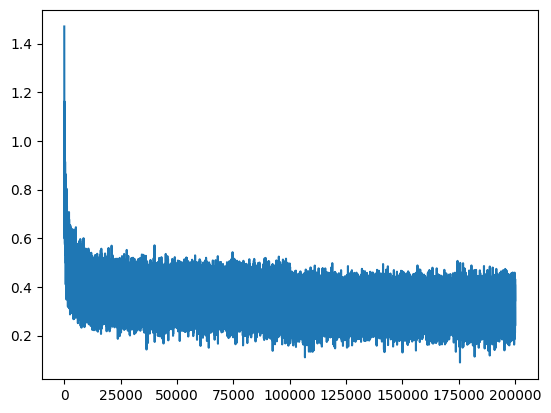

In [208]:
plt.plot(stepi, lossi)
plt.show()

#### Create text

In [209]:
emb_size = 10
hidden_size = 200

In [215]:
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
    out = []
    contex = [0] * 3
    
    while True:
        emb = C[torch.tensor(contex)]  # 3,10. C is tensor, so it is better to turn contex to tensor for advance slicing
        h = torch.tanh(emb.view(1, -1) @ w1 + b1) # 1,30. because we have just one sample and want to flatten emb we can use emb.view(1, -1) .Or we can use emb.view(-1, 3*emb_size)
        logits = h @ w2 + b2 # 1,27
        probs = F.softmax(logits, dim = 1)
        ix = torch.multinomial(probs, num_samples = 1, replacement = True, generator = g).item()
        if ix:
            contex = contex[1:] + [ix]
            out.append(itos[ix])
        else:
            break
    print(''.join(out))        

junide
jakasaz
partarie
nai
jirritopera
juett
damela
yamilena
jadeyaine
immadse
